# Лабораторная работа №1  
## Анализ и прогнозирование временных рядов на примере розничных продаж


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.fft import rfft, rfftfreq
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from sklearn.metrics import mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

## 1. Загрузка и первичная подготовка данных

In [ ]:
DATA_PATH = 'retail_sales_mock_data.csv'

# Загружаем данные, преобразуем дату и задаём месячную частоту временного ряда
df = pd.read_csv(DATA_PATH, parse_dates=['Date'])
df = df.sort_values('Date').set_index('Date').asfreq('MS')

# Проверяем пропуски и типы данных
display(df.head())
display(df.info())
display(df.describe())
print('Пропуски по столбцам:')
print(df.isna().sum())

,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 48 entries, 2020-01-01 to 2023-12-01
Freq: MS
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   SalesAmount   48 non-null     int64
 1   Promotion     48 non-null     int64
 2   HolidayMonth  48 non-null     int64
dtypes: int64(3)
memory usage: 1.5 KB


None

,SalesAmount,Promotion,HolidayMonth
count,48.000,48.000,48.000
mean,"11,768.542",0.125,0.083
std,"2,257.545",0.334,0.279
min,"7,783.000",0.000,0.000
25%,"10,219.750",0.000,0.000
50%,"11,851.000",0.000,0.000
75%,"13,014.000",0.000,0.000
max,"17,996.000",1.000,1.000


Пропуски по столбцам:
SalesAmount     0
Promotion       0
HolidayMonth    0
dtype: int64


In [ ]:
# Целевая переменная и потенциальные экзогенные признаки
y = df['SalesAmount'].astype(float)
exog = df[['Promotion', 'HolidayMonth']].astype(float)

print(f'Период наблюдений: {df.index.min().date()} — {df.index.max().date()}')
print(f'Количество наблюдений: {len(df)}')
print(f'Частота ряда: {pd.infer_freq(df.index)}')

Период наблюдений: 2020-01-01 — 2023-12-01
Количество наблюдений: 48
Частота ряда: MS


### Аналитический вывод по пункту 1
Данные представляют собой регулярный месячный временной ряд без пропусков. Целевой показатель — `SalesAmount`; признаки `Promotion` и `HolidayMonth` можно использовать как экзогенные переменные в SARIMAX, так как они описывают внешние факторы, потенциально влияющие на продажи.

## 2. Разведочный анализ данных (EDA)

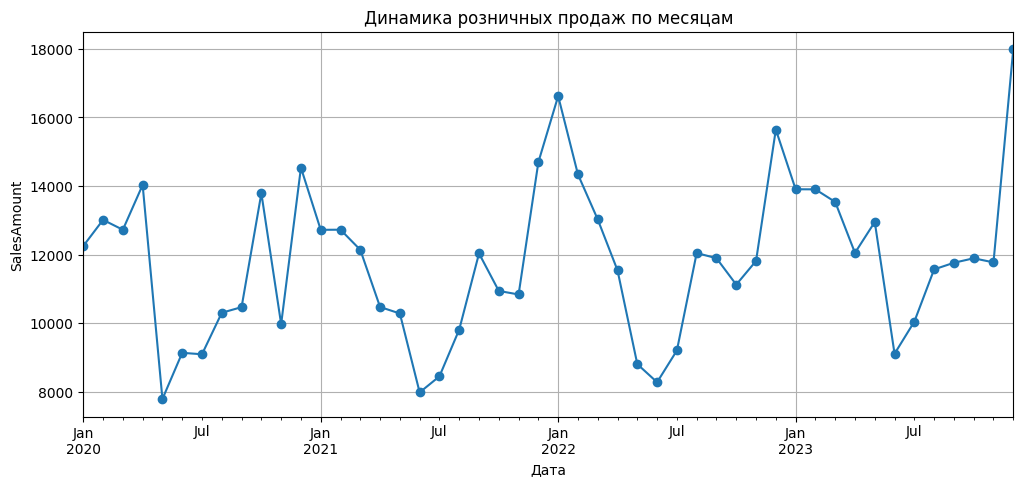

In [ ]:
fig, ax = plt.subplots()
y.plot(ax=ax, marker='o')
ax.set_title('Динамика розничных продаж по месяцам')
ax.set_xlabel('Дата')
ax.set_ylabel('SalesAmount')
plt.show()

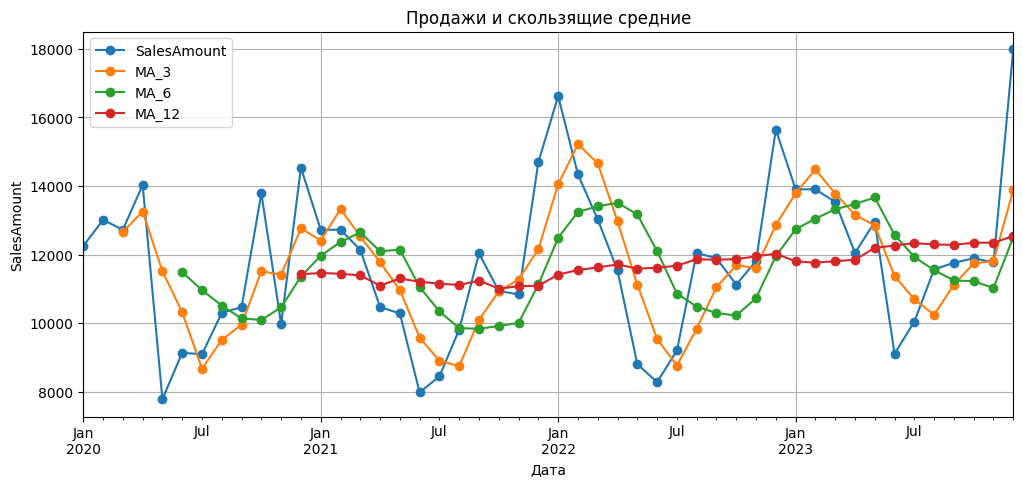

In [ ]:
# Скользящие средние
roll = pd.DataFrame({
    'SalesAmount': y,
    'MA_3': y.rolling(3).mean(),
    'MA_6': y.rolling(6).mean(),
    'MA_12': y.rolling(12).mean()
})

ax = roll.plot(marker='o')
ax.set_title('Продажи и скользящие средние')
ax.set_xlabel('Дата')
ax.set_ylabel('SalesAmount')
plt.show()

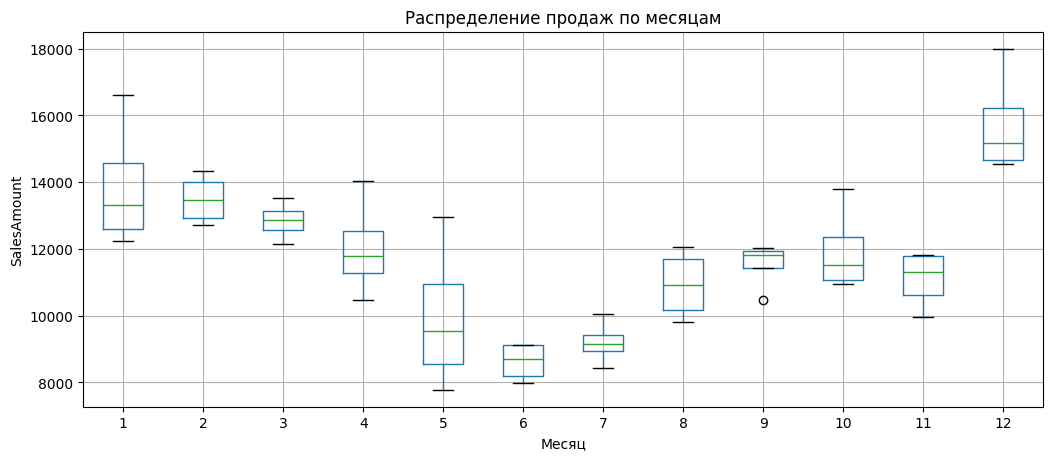

Year,2020,2021,2022,2023
Month,,,,
1,"12,248.000","12,720.000","16,623.000","13,904.000"
2,"13,011.000","12,724.000","14,336.000","13,901.000"
3,"12,722.000","12,136.000","13,023.000","13,534.000"
4,"14,030.000","10,468.000","11,537.000","12,048.000"
5,"7,783.000","10,279.000","8,800.000","12,949.000"
6,"9,131.000","7,976.000","8,273.000","9,104.000"
7,"9,089.000","8,445.000","9,199.000","10,042.000"
8,"10,300.000","9,810.000","12,043.000","11,566.000"
9,"10,464.000","12,031.000","11,892.000","11,759.000"


In [ ]:
# Сезонные профили по месяца
monthly = df.assign(Month=df.index.month, Year=df.index.year)

fig, ax = plt.subplots()
monthly.boxplot(column='SalesAmount', by='Month', ax=ax)
ax.set_title('Распределение продаж по месяцам')
ax.set_xlabel('Месяц')
ax.set_ylabel('SalesAmount')
plt.suptitle('')
plt.show()

pivot = monthly.pivot_table(index='Month', columns='Year', values='SalesAmount')
display(pivot)

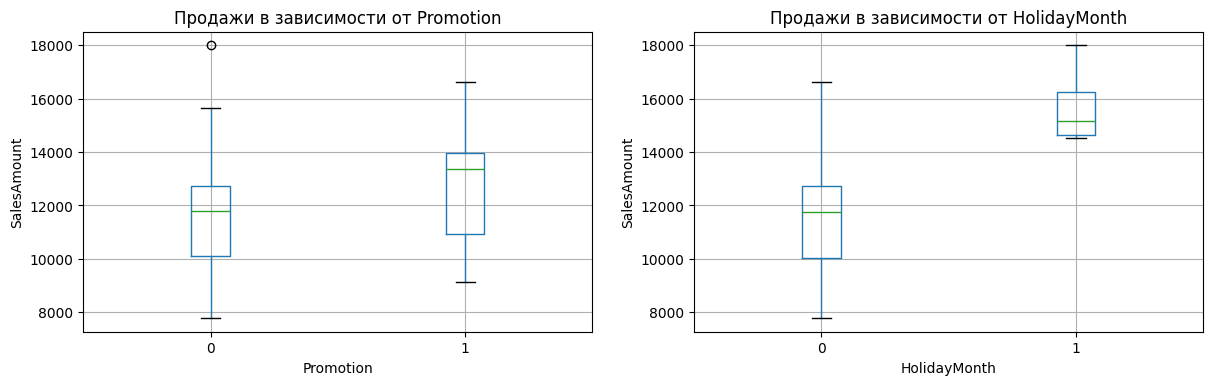

,count,mean,median,std
Promotion,,,,
0,42,"11,621.238","11,791.000","2,182.556"
1,6,"12,799.667","13,367.500","2,718.074"


,count,mean,median,std
HolidayMonth,,,,
0,44,"11,409.523","11,764.500","1,951.973"
1,4,"15,717.750","15,170.500","1,595.927"


In [ ]:
# Связь продаж с промо и праздничными месяцами
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df.boxplot(column='SalesAmount', by='Promotion', ax=axes[0])
axes[0].set_title('Продажи в зависимости от Promotion')
axes[0].set_xlabel('Promotion')
axes[0].set_ylabel('SalesAmount')

df.boxplot(column='SalesAmount', by='HolidayMonth', ax=axes[1])
axes[1].set_title('Продажи в зависимости от HolidayMonth')
axes[1].set_xlabel('HolidayMonth')
axes[1].set_ylabel('SalesAmount')
plt.suptitle('')
plt.show()

display(df.groupby('Promotion')['SalesAmount'].agg(['count', 'mean', 'median', 'std']))
display(df.groupby('HolidayMonth')['SalesAmount'].agg(['count', 'mean', 'median', 'std']))

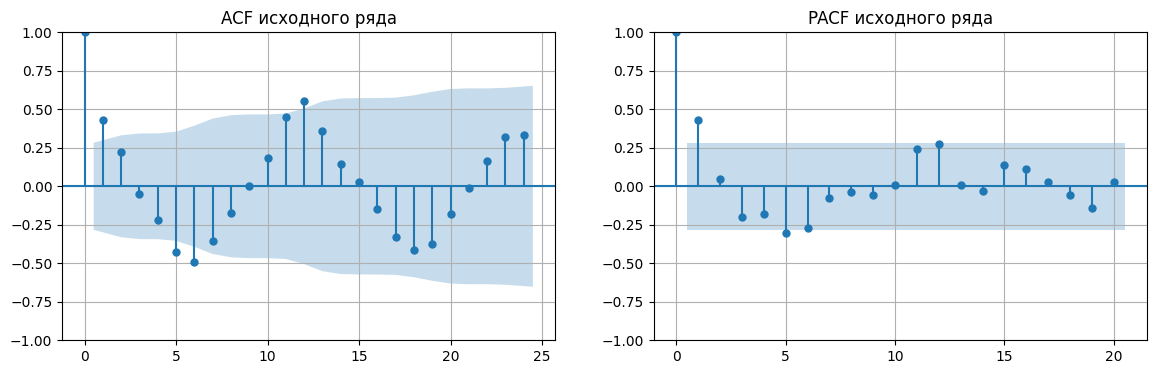

ADF statistic: -4.514
p-value: 0.0002
Интерпретация: p-value < 0.05 говорит в пользу стационарности; иначе требуется дифференцирование.


In [ ]:
# ACF/PACF позволяют оценить автокорреляцию и подобрать стартовые параметры ARIMA/SARIMAX
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y, lags=24, ax=axes[0])
plot_pacf(y, lags=20, ax=axes[1], method='ywm')
axes[0].set_title('ACF исходного ряда')
axes[1].set_title('PACF исходного ряда')
plt.show()

adf_stat, p_value, *_ = adfuller(y)
print(f'ADF statistic: {adf_stat:.3f}')
print(f'p-value: {p_value:.4f}')
print('Интерпретация: p-value < 0.05 говорит в пользу стационарности; иначе требуется дифференцирование.')

### Аналитический вывод по пункту 2
Временной ряд имеет заметные колебания и повторяющиеся годовые паттерны, что типично для месячных продаж. Скользящая средняя показывает изменение общего уровня продаж, а сезонные профили позволяют предположить наличие годовой сезонности с периодом 12 месяцев. Поэтому при моделировании целесообразно сравнить несезонную ARIMA и сезонную SARIMAX с периодом `s=12`, а также добавить `Promotion` и `HolidayMonth` как экзогенные факторы.

## 3. Декомпозиция временного ряда тремя методами

### 3.1 Классическая аддитивная, мультипликативная и STL-декомпозиция

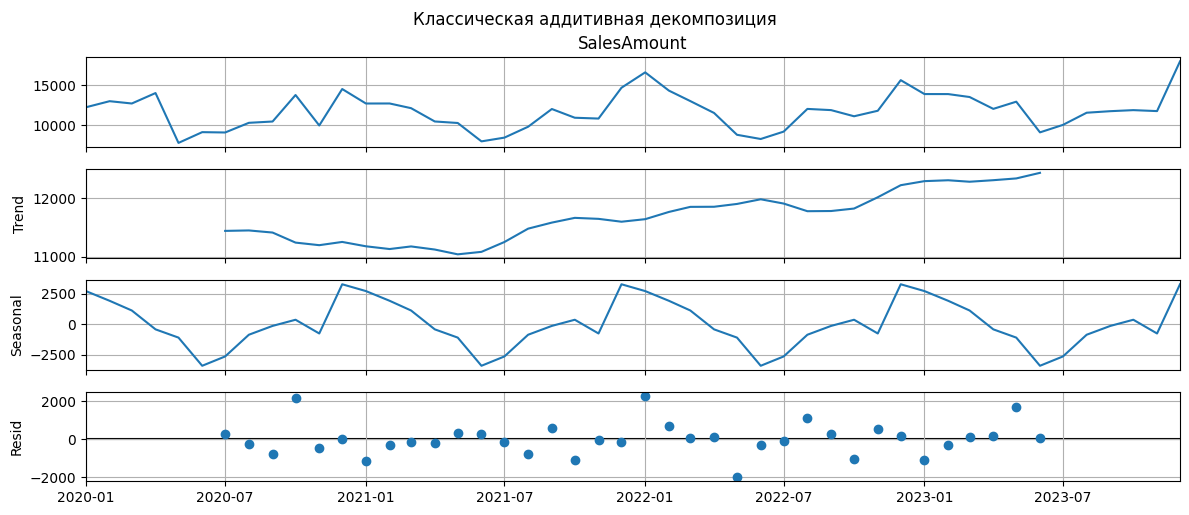

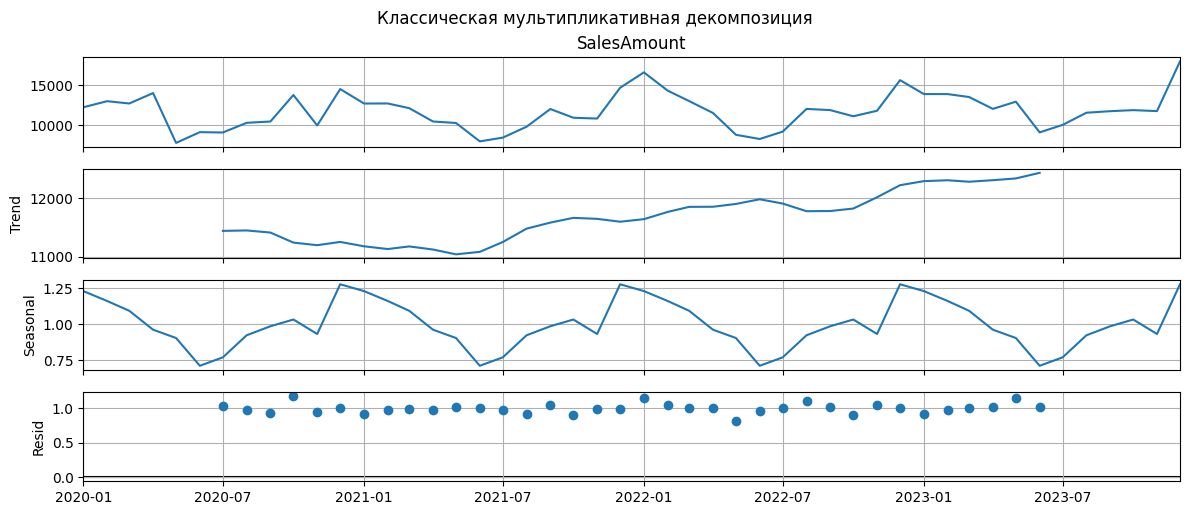

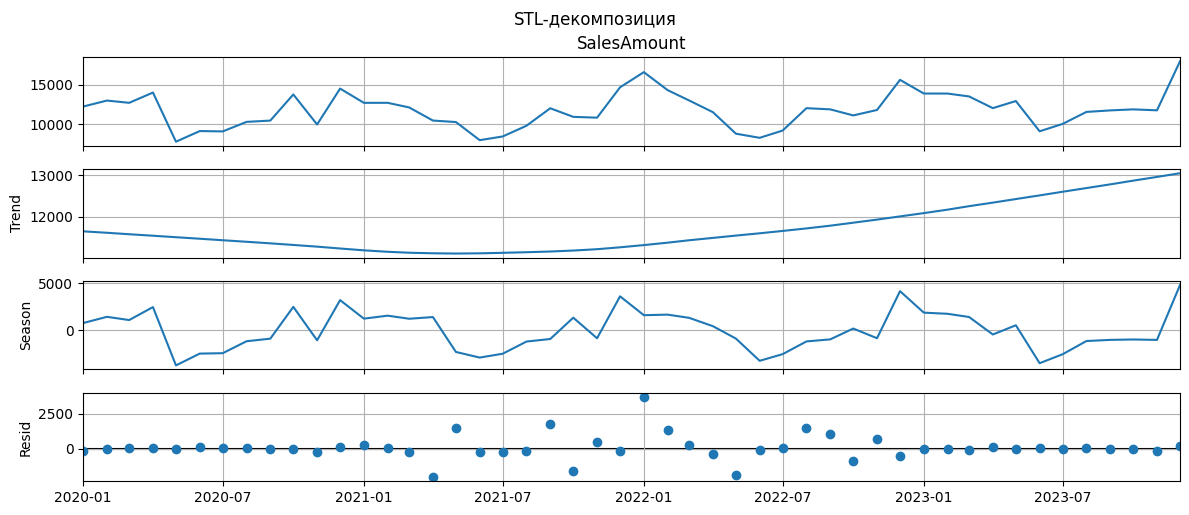

In [ ]:
period = 12

add_decomp = seasonal_decompose(y, model='additive', period=period)
mult_decomp = seasonal_decompose(y, model='multiplicative', period=period)
stl_decomp = STL(y, period=period, robust=True).fit()

add_decomp.plot()
plt.suptitle('Классическая аддитивная декомпозиция', y=1.02)
plt.show()

mult_decomp.plot()
plt.suptitle('Классическая мультипликативная декомпозиция', y=1.02)
plt.show()

stl_decomp.plot()
plt.suptitle('STL-декомпозиция', y=1.02)
plt.show()

### 3.2 Спектральный анализ с FFT

,frequency_per_month,amplitude,period_months
4,0.083,"57,678.597",12.000
12,0.250,"20,504.205",4.000
24,0.500,"16,836.000",2.000
1,0.021,"14,794.640",48.000
20,0.417,"13,539.812",2.400
23,0.479,"13,082.050",2.087
22,0.458,"12,407.895",2.182
8,0.167,"12,263.057",6.000
13,0.271,"12,236.138",3.692
14,0.292,"11,466.966",3.429


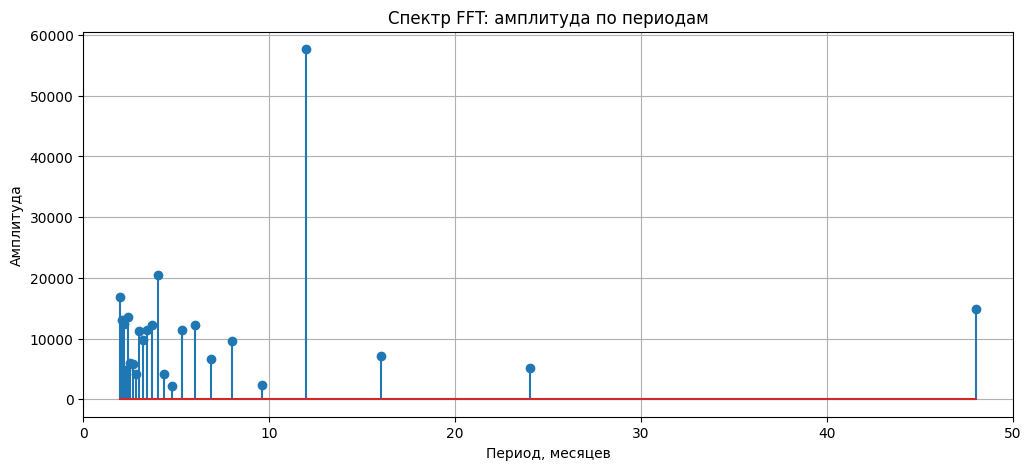

In [ ]:
# FFT выявляет доминирующие частоты. Предварительно центрируем ряд
y_centered = y - y.mean()
fft_values = np.abs(rfft(y_centered.values))
freqs = rfftfreq(len(y_centered), d=1)  # d=1 месяц

# Исключаем нулевую частоту, отвечающую за средний уровень
fft_table = pd.DataFrame({'frequency_per_month': freqs, 'amplitude': fft_values})
fft_table = fft_table[fft_table['frequency_per_month'] > 0].copy()
fft_table['period_months'] = 1 / fft_table['frequency_per_month']
fft_top = fft_table.sort_values('amplitude', ascending=False).head(10)
display(fft_top)

fig, ax = plt.subplots()
ax.stem(fft_table['period_months'], fft_table['amplitude'])
ax.set_xlim(0, 50)
ax.set_title('Спектр FFT: амплитуда по периодам')
ax.set_xlabel('Период, месяцев')
ax.set_ylabel('Амплитуда')
plt.show()

### 3.3 Вейвлет-анализ на основе комплексного вейвлета Морле

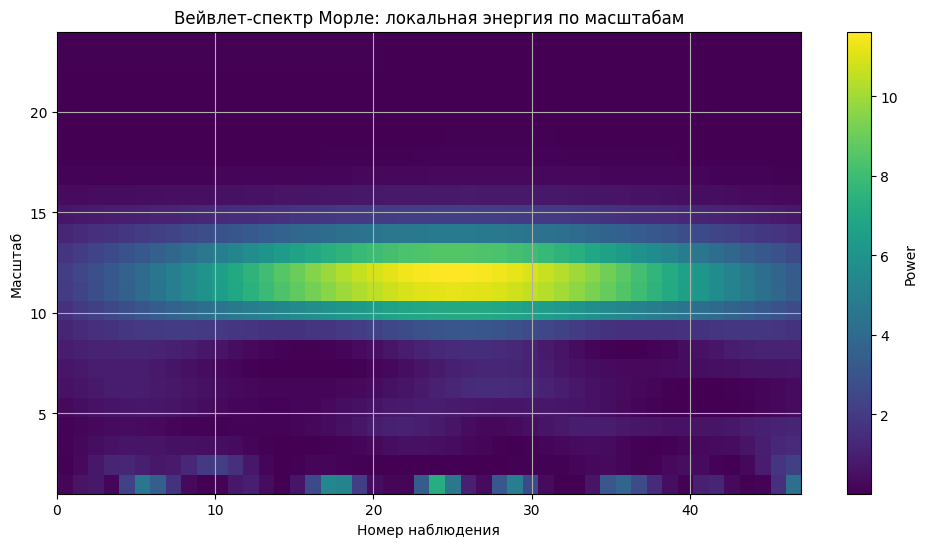

,scale,mean_power
11,12,7.759
10,11,7.570
12,13,5.769
9,10,4.952
13,14,3.311
8,9,2.038
0,1,1.699
14,15,1.530
7,8,0.733
15,16,0.583


In [ ]:
# Реализуем CWT
def morlet_wavelet(scale, w=6.0):
    """Комплексный вейвлет Морле для заданного масштаба."""
    half_width = int(max(10, np.ceil(6 * scale)))
    t = np.arange(-half_width, half_width + 1)
    wavelet = (np.pi ** -0.25) * np.exp(1j * w * t / scale) * np.exp(-(t ** 2) / (2 * scale ** 2))
    wavelet = wavelet / np.sqrt(scale)
    return wavelet

def cwt_morlet(signal, scales):
    """Непрерывное вейвлет-преобразование через свёртку с вейвлетом Морле."""
    coeffs = []
    for scale in scales:
        wavelet = morlet_wavelet(scale)
        coeff_full = np.convolve(signal, np.conj(wavelet[::-1]), mode='same')
        # Если вейвлет длиннее сигнала, np.convolve(mode='same') возвращает длину вейвлета
        # Обрезаем центр до длины исходного временного ряда
        if len(coeff_full) != len(signal):
            start = (len(coeff_full) - len(signal)) // 2
            coeff_full = coeff_full[start:start + len(signal)]
        coeffs.append(coeff_full)
    return np.array(coeffs)

signal = ((y - y.mean()) / y.std()).values
scales = np.arange(1, 25)
coeffs = cwt_morlet(signal, scales)
power = np.abs(coeffs) ** 2

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(power, aspect='auto', origin='lower', extent=[0, len(y)-1, scales.min(), scales.max()])
ax.set_title('Вейвлет-спектр Морле: локальная энергия по масштабам')
ax.set_xlabel('Номер наблюдения')
ax.set_ylabel('Масштаб')
fig.colorbar(im, ax=ax, label='Power')
plt.show()

wavelet_summary = pd.DataFrame({'scale': scales, 'mean_power': power.mean(axis=1)})
display(wavelet_summary.sort_values('mean_power', ascending=False).head(10))

### Сравнение методов декомпозиции

| Метод | Что показывает | Преимущества | Ограничения | Применимость к данным |
|---|---|---|---|---|
| Классическая аддитивная / мультипликативная декомпозиция | Тренд, сезонность, остаток | Простая интерпретация, хорошо подходит для регулярного сезонного ряда | Требует заранее заданный период, чувствительна к выбросам и короткой истории | Подходит, так как данные месячные и есть годовой сезонный цикл |
| STL | Гибкое разделение тренда, сезонности и остатка | Устойчивее к выбросам, гибче классической декомпозиции | Нужен сезонный период, качество ограничено длиной ряда | Наиболее удобна для EDA этого ряда |
| FFT | Доминирующие частоты и периоды | Хорошо выявляет глобальную периодичность | Не показывает, когда именно меняется сезонность; предполагает стационарность частот | Полезен для подтверждения годовой периодичности |
| Вейвлет-анализ | Локальная частотно-временная структура | Показывает изменение периодичности во времени | Менее простая интерпретация, зависит от выбора вейвлета и масштаба | Полезен как дополнительная проверка нестабильности сезонности |
|

### Аналитический вывод по пункту 3
Классическая и STL-декомпозиции подтверждают наличие трендовой и сезонной составляющих. FFT позволяет выделить доминирующие циклы, в том числе периоды, близкие к годовому сезонному циклу. Вейвлет-анализ показывает, насколько устойчивы колебания на разных масштабах во времени. Для построения прогноза наиболее практически полезны STL/классическая декомпозиция и ACF/PACF, поскольку они прямо указывают на необходимость сезонной модели с периодом 12.

## 4. Построение прогнозных моделей ARIMA и SARIMAX

In [ ]:
# Последние 12 месяцев используем для проверки прогноза
test_size = 12
train_y, test_y = y.iloc[:-test_size], y.iloc[-test_size:]
train_exog, test_exog = exog.iloc[:-test_size], exog.iloc[-test_size:]

print(f'Обучение: {train_y.index.min().date()} — {train_y.index.max().date()} ({len(train_y)} наблюдений)')
print(f'Тест:     {test_y.index.min().date()} — {test_y.index.max().date()} ({len(test_y)} наблюдений)')

Обучение: 2020-01-01 — 2022-12-01 (36 наблюдений)
Тест:     2023-01-01 — 2023-12-01 (12 наблюдений)


In [ ]:
# Для SARIMAX используем сезонность 12 месяцев и экзогенные признаки Promotion, HolidayMonth

def fit_and_evaluate(model_name, order, seasonal_order=(0, 0, 0, 0), use_exog=False):
    model = SARIMAX(
        train_y,
        exog=train_exog if use_exog else None,
        order=order,
        seasonal_order=seasonal_order,
        trend='c',
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    result = model.fit(disp=False, maxiter=200)
    forecast = result.forecast(steps=len(test_y), exog=test_exog if use_exog else None)
    return {
        'model': model_name,
        'order': order,
        'seasonal_order': seasonal_order,
        'use_exog': use_exog,
        'aic': result.aic,
        'bic': result.bic,
        'mse': mean_squared_error(test_y, forecast),
        'r2': r2_score(test_y, forecast),
        'result': result,
        'forecast': forecast
    }

candidate_specs = []
for p in [0, 1, 2]:
    for d in [0, 1]:
        for q in [0, 1, 2]:
            if (p, d, q) != (0, 0, 0):
                candidate_specs.append(('ARIMA', (p, d, q), (0, 0, 0, 0), False))

# Несколько сезонных спецификаций, подобранных по итогам EDA и ACF/PACF
for order in [(1, 1, 1), (1, 1, 0), (0, 1, 1), (1, 0, 1), (2, 0, 1)]:
    for seasonal_order in [(1, 0, 1, 12), (1, 1, 0, 12), (0, 1, 1, 12)]:
        candidate_specs.append(('SARIMAX', order, seasonal_order, True))

results = []
for spec in candidate_specs:
    try:
        results.append(fit_and_evaluate(*spec))
    except Exception as e:
        pass

metrics = pd.DataFrame([{k: v for k, v in r.items() if k not in ['result', 'forecast']} for r in results])
metrics = metrics.sort_values(['mse', 'aic']).reset_index(drop=True)
display(metrics.head(15))

def find_result_by_row(row):
    for r in results:
        if (r['model'] == row['model'] and r['order'] == row['order'] and
            r['seasonal_order'] == row['seasonal_order'] and r['use_exog'] == row['use_exog']):
            return r
    raise ValueError('Model not found')

best = find_result_by_row(metrics.loc[0])
print('Лучшая модель по MSE:')
print(best['model'], best['order'], best['seasonal_order'], 'use_exog=', best['use_exog'])

/opt/pyvenv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,model,order,seasonal_order,use_exog,aic,bic,mse,r2
0,SARIMAX,"(1, 0, 1)","(1, 1, 0, 12)",True,182.709,185.494,"590,540.997",0.872
1,SARIMAX,"(1, 0, 1)","(0, 1, 1, 12)",True,162.527,164.645,"596,680.703",0.871
2,SARIMAX,"(2, 0, 1)","(0, 1, 1, 12)",True,159.190,161.611,"599,064.989",0.870
3,SARIMAX,"(2, 0, 1)","(1, 1, 0, 12)",True,165.897,168.317,"615,592.035",0.867
4,SARIMAX,"(1, 1, 0)","(1, 1, 0, 12)",True,169.490,171.306,"623,519.313",0.865
5,SARIMAX,"(1, 1, 1)","(1, 1, 0, 12)",True,168.562,170.680,"677,041.070",0.854
6,SARIMAX,"(0, 1, 1)","(1, 1, 0, 12)",True,182.339,184.726,"679,181.827",0.853
7,SARIMAX,"(1, 1, 1)","(0, 1, 1, 12)",True,151.771,153.151,"833,788.943",0.820
8,SARIMAX,"(0, 1, 1)","(0, 1, 1, 12)",True,150.745,151.928,"979,757.489",0.788
9,SARIMAX,"(1, 1, 0)","(1, 0, 1, 12)",True,372.653,380.290,"1,055,529.253",0.772


Лучшая модель по MSE:
SARIMAX (1, 0, 1) (1, 1, 0, 12) use_exog= True


In [ ]:
# Для сравнения берём лучшую ARIMA и лучшую SARIMAX:
best_arima_row = metrics[metrics['model'] == 'ARIMA'].iloc[0]
best_sarimax_row = metrics[metrics['model'] == 'SARIMAX'].iloc[0]

def find_result(row):
    for r in results:
        if (r['model'] == row['model'] and r['order'] == row['order'] and
            r['seasonal_order'] == row['seasonal_order'] and r['use_exog'] == row['use_exog']):
            return r
    raise ValueError('Model not found')

best_arima = find_result(best_arima_row)
best_sarimax = find_result(best_sarimax_row)
comparison = pd.DataFrame([
    {k: v for k, v in best_arima.items() if k not in ['result', 'forecast']},
    {k: v for k, v in best_sarimax.items() if k not in ['result', 'forecast']}
])
display(comparison)

,model,order,seasonal_order,use_exog,aic,bic,mse,r2
0,ARIMA,"(1, 0, 0)","(0, 0, 0, 0)",False,635.670,640.336,"4,612,397.917",0.003
1,SARIMAX,"(1, 0, 1)","(1, 1, 0, 12)",True,182.709,185.494,"590,540.997",0.872


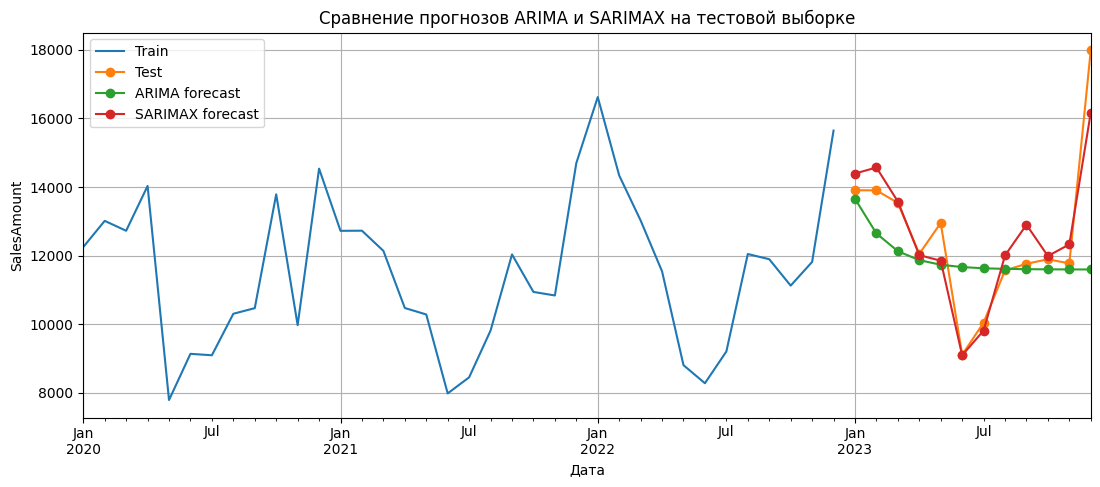

In [ ]:
# График прогноза на тестовом периоде
fig, ax = plt.subplots(figsize=(13, 5))
train_y.plot(ax=ax, label='Train')
test_y.plot(ax=ax, label='Test', marker='o')
best_arima['forecast'].plot(ax=ax, label='ARIMA forecast', marker='o')
best_sarimax['forecast'].plot(ax=ax, label='SARIMAX forecast', marker='o')
ax.set_title('Сравнение прогнозов ARIMA и SARIMAX на тестовой выборке')
ax.set_xlabel('Дата')
ax.set_ylabel('SalesAmount')
ax.legend()
plt.show()

### Аналитический вывод по пункту 4
Параметры моделей подбирались с учётом EDA: для ARIMA проверялись малые значения `p`, `d`, `q`, а для SARIMAX добавлялась сезонная часть с периодом 12 месяцев и экзогенные признаки `Promotion`, `HolidayMonth`. Из-за короткой истории данных использован ограниченный перебор параметров, чтобы избежать переобучения и нестабильной оценки параметров.

## 5. Оценка качества моделей и анализ остатков

In [ ]:
# Таблица качества: MSE, R2, AIC, BIC
quality_table = comparison[['model', 'order', 'seasonal_order', 'use_exog', 'mse', 'r2', 'aic', 'bic']].copy()
display(quality_table.sort_values('mse'))

,model,order,seasonal_order,use_exog,mse,r2,aic,bic
1,SARIMAX,"(1, 0, 1)","(1, 1, 0, 12)",True,"590,540.997",0.872,182.709,185.494
0,ARIMA,"(1, 0, 0)","(0, 0, 0, 0)",False,"4,612,397.917",0.003,635.670,640.336


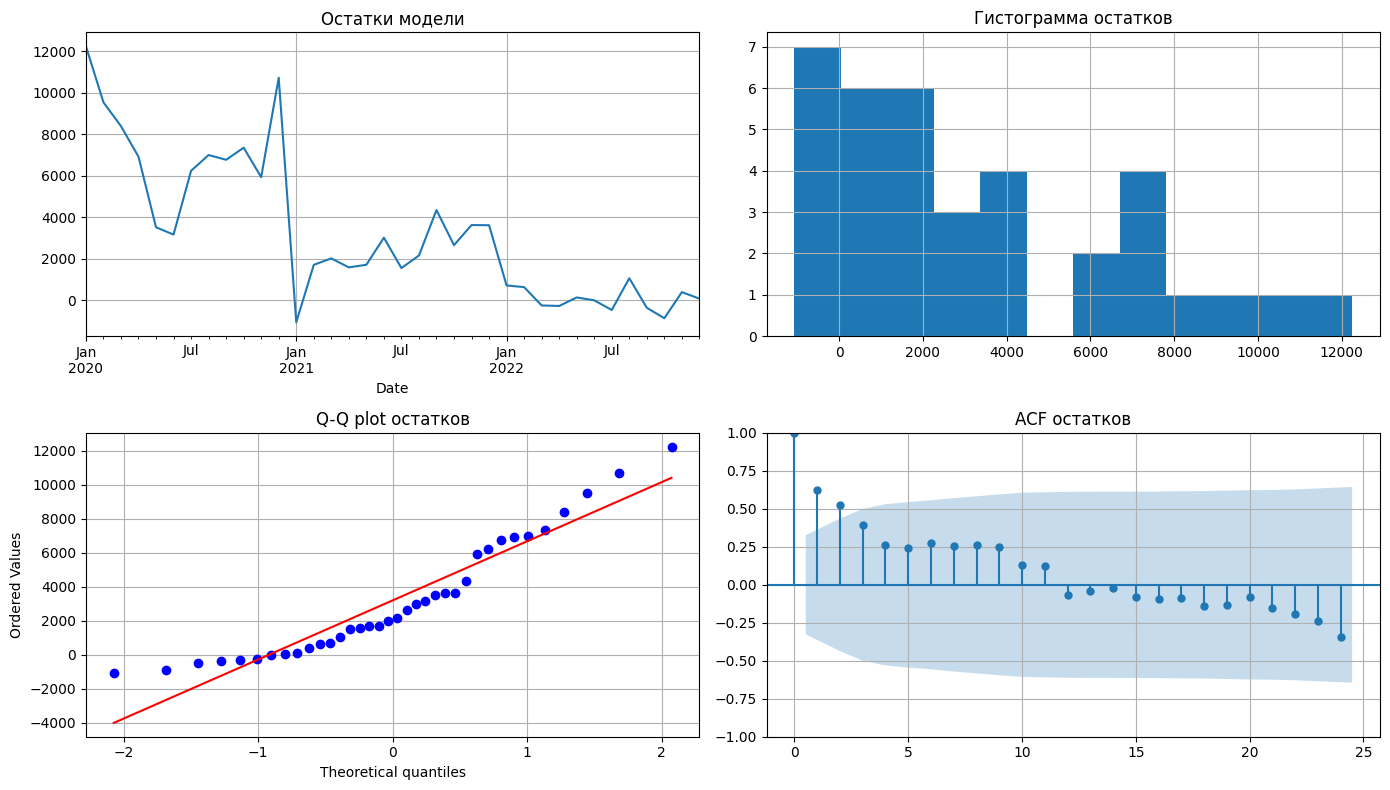

In [ ]:
# Анализ остатков лучшей SARIMAX-модели
selected = best_sarimax if best_sarimax['mse'] <= best_arima['mse'] else best_arima
residuals = selected['result'].resid.dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
residuals.plot(ax=axes[0, 0])
axes[0, 0].set_title('Остатки модели')

axes[0, 1].hist(residuals, bins=12)
axes[0, 1].set_title('Гистограмма остатков')

stats.probplot(residuals, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Q-Q plot остатков')

plot_acf(residuals, lags=min(24, len(residuals)-1), ax=axes[1, 1])
axes[1, 1].set_title('ACF остатков')
plt.tight_layout()
plt.show()

In [ ]:
# Статистические тесты по остаткам

shapiro_stat, shapiro_p = stats.shapiro(residuals)
ljung = acorr_ljungbox(residuals, lags=[min(12, len(residuals)//2)], return_df=True)
arch_stat, arch_p, _, _ = het_arch(residuals, nlags=min(6, len(residuals)//3))

residual_tests = pd.DataFrame({
    'test': ['Shapiro-Wilk normality', 'Ljung-Box autocorrelation', 'ARCH heteroskedasticity'],
    'statistic': [shapiro_stat, ljung['lb_stat'].iloc[0], arch_stat],
    'p_value': [shapiro_p, ljung['lb_pvalue'].iloc[0], arch_p],
    'H0': [
        'остатки нормальны',
        'остатки не автокоррелированы',
        'нет ARCH-гетероскедастичности'
    ]
})
display(residual_tests)

print('Выбранная модель:', selected['model'], selected['order'], selected['seasonal_order'])

,test,statistic,p_value,H0
0,Shapiro-Wilk normality,0.904,0.004,остатки нормальны
1,Ljung-Box autocorrelation,53.470,0.000,остатки не автокоррелированы
2,ARCH heteroskedasticity,8.943,0.177,нет ARCH-гетероскедастичности


Выбранная модель: SARIMAX (1, 0, 1) (1, 1, 0, 12)


,forecast,lower_ci,upper_ci,Promotion_scenario,HolidayMonth_scenario
2024-01-01,"14,346.525","13,158.189","15,534.862",0,0
2024-02-01,"15,113.235","13,916.917","16,309.553",0,0
2024-03-01,"14,303.235","13,105.842","15,500.628",0,0
2024-04-01,"12,830.083","11,632.544","14,027.621",0,0
2024-05-01,"10,106.993","8,909.434","11,304.551",0,0
2024-06-01,"9,730.873","8,533.312","10,928.434",0,0
2024-07-01,"10,663.449","9,465.888","11,861.010",0,0
2024-08-01,"12,854.576","11,657.015","14,052.138",0,0
2024-09-01,"12,873.867","11,676.305","14,071.428",0,0
2024-10-01,"12,549.189","11,351.627","13,746.750",0,0


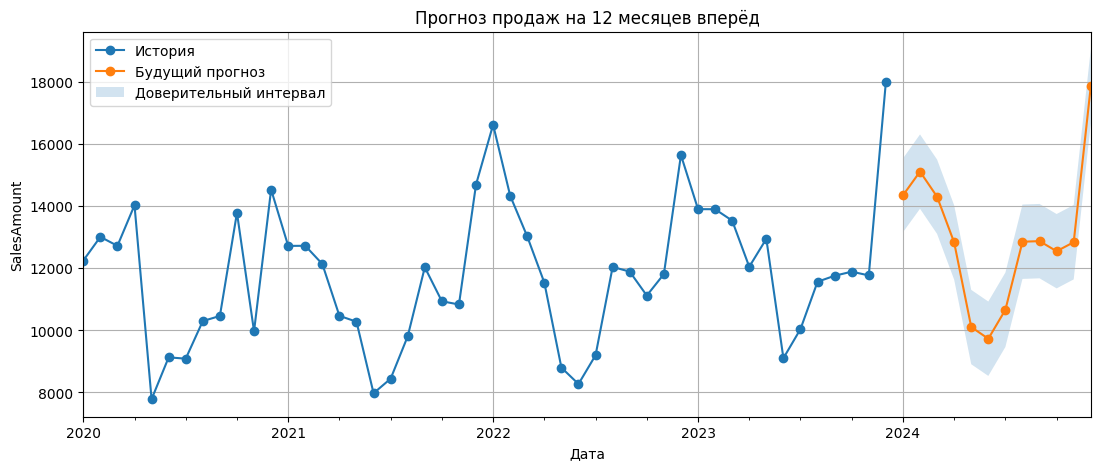

In [ ]:
# Прогноз на максимально возможный практический горизонт
forecast_horizon = 12

# Нейтральный сценарий без промо и праздников,
# кроме декабря как праздничного месяца. При наличии бизнес-плана эти признаки следует заменить реальным планом.
future_index = pd.date_range(y.index.max() + pd.offsets.MonthBegin(1), periods=forecast_horizon, freq='MS')
future_exog = pd.DataFrame(index=future_index)
future_exog['Promotion'] = 0
future_exog['HolidayMonth'] = (future_exog.index.month == 12).astype(int)

# Переобучение SARIMAX-модели на всей истории и строим будущий прогноз
final_model = SARIMAX(
    y,
    exog=exog if selected['use_exog'] else None,
    order=selected['order'],
    seasonal_order=selected['seasonal_order'],
    trend='c',
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, maxiter=200)

future_forecast_res = final_model.get_forecast(
    steps=forecast_horizon,
    exog=future_exog if selected['use_exog'] else None
)
future_forecast = future_forecast_res.predicted_mean
future_ci = future_forecast_res.conf_int()

display(pd.DataFrame({
    'forecast': future_forecast,
    'lower_ci': future_ci.iloc[:, 0],
    'upper_ci': future_ci.iloc[:, 1],
    'Promotion_scenario': future_exog['Promotion'] if selected['use_exog'] else np.nan,
    'HolidayMonth_scenario': future_exog['HolidayMonth'] if selected['use_exog'] else np.nan
}))

fig, ax = plt.subplots(figsize=(13, 5))
y.plot(ax=ax, label='История', marker='o')
future_forecast.plot(ax=ax, label='Будущий прогноз', marker='o')
ax.fill_between(future_ci.index, future_ci.iloc[:, 0], future_ci.iloc[:, 1], alpha=0.2, label='Доверительный интервал')
ax.set_title('Прогноз продаж на 12 месяцев вперёд')
ax.set_xlabel('Дата')
ax.set_ylabel('SalesAmount')
ax.legend()
plt.show()

### Аналитический вывод по пункту 5
Сравнение моделей проводится по MSE, R², AIC и BIC. Если SARIMAX показывает меньшую ошибку и лучшие информационные критерии, это означает, что сезонность и экзогенные признаки действительно улучшают описание ряда. Анализ остатков нужен для проверки того, осталась ли в ошибках систематическая структура. Предпочтительной считается модель с меньшим MSE/AIC/BIC, более высоким R² и остатками, близкими к белому шуму.

## Итоговый вывод

1. Ряд розничных продаж является регулярным месячным временным рядом с выраженной сезонной структурой.  
2. Декомпозиции подтверждают наличие тренда, сезонности и остаточной компоненты; FFT и вейвлет-анализ дополняют классическую декомпозицию частотным и частотно-временным взглядом.  
3. Для прогноза целесообразно использовать SARIMAX, потому что она учитывает сезонность 12 месяцев и внешние факторы `Promotion`/`HolidayMonth`.  
4. Финальное решение о предпочтительной модели принимается по совокупности MSE, R², AIC, BIC и диагностики остатков.  
5. Горизонт прогноза 12 месяцев выбран как практически разумный максимум для имеющихся 48 месячных наблюдений; более длинный прогноз возможен технически, но будет иметь существенно более широкую неопределённость.
